# South African Spam Email Classification - Complete Pipeline

## End-to-End Data Science & Machine Learning Implementation

###  Project Overview
This notebook implements a complete spam classification system using:
- **Logistic Regression**
- **Naive Bayes (MultinomialNB)**
- **Support Vector Machine (SVM)**
- **Ensemble Model (Voting Classifier)**

### Pipeline Stages
1. Data Loading & Exploration
2. Exploratory Data Analysis (EDA)
3. Data Cleaning & Preprocessing
4. Feature Engineering (TF-IDF)
5. Model Training (LR, NB, SVM)
6. Ensemble Model Creation
7. Model Evaluation & Comparison
8. Production Predictions

---
## 1. Setup & Installations

In [10]:
# Install required packages
!pip install -q wordcloud imbalanced-learn

In [11]:
# Core libraries for data manipulation and general utilities
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter
import re
import string
from datetime import datetime

# Text processing libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from wordcloud import WordCloud

# Machine Learning preprocessing tools
from sklearn.model_selection import (
    train_test_split, cross_val_score,  # For splitting data and cross-validation
    StratifiedKFold, GridSearchCV      # For stratified splitting and hyperparameter tuning
)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer # For text feature extraction
from sklearn.preprocessing import LabelEncoder # For encoding categorical labels

# Machine Learning models - The core algorithms used in this project
from sklearn.naive_bayes import MultinomialNB # Naive Bayes classifier for text data
from sklearn.linear_model import LogisticRegression # Logistic Regression classifier
from sklearn.svm import SVC, LinearSVC # Support Vector Machine classifiers

# Ensemble model for combining predictions from multiple models
from sklearn.ensemble import VotingClassifier

# Evaluation metrics to assess model performance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, # Basic classification metrics
    confusion_matrix, classification_report,                 # Detailed report and confusion matrix
    roc_curve, auc, roc_auc_score,                          # ROC curve and Area Under the Curve
    precision_recall_curve, average_precision_score         # Precision-Recall curve and Average Precision
)

# General settings for the notebook
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output
sns.set_style('whitegrid') # Set seaborn style for plots
plt.rcParams['figure.figsize'] = (14, 6) # Default figure size for matplotlib plots
pd.set_option('display.max_columns', None) # Display all columns in pandas DataFrames
pd.set_option('display.max_colwidth', 100) # Set max column width for displaying text

# Set a global random seed for reproducibility across runs
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Download necessary NLTK resources if not already present
print("Downloading NLTK resources...")
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("\nAll libraries imported successfully!")
print(f"Notebook initialized: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


All libraries imported successfully!
Notebook initialized: 2026-05-21 17:31:10


---
## 2. Data Loading & Initial Exploration

In [8]:
# This cell is responsible for handling the dataset upload from the local system to the Colab environment.

from google.colab import files # Import the 'files' module from google.colab for file upload functionality.

print("Please upload your spam dataset CSV file...\n") # Prompt the user to upload a CSV file.

# Call the upload() method, which opens a file selection dialog in the browser.
# The uploaded content is stored in a dictionary, where keys are filenames and values are file contents.
uploaded = files.upload()

# Extract the filename from the 'uploaded' dictionary. Assuming only one file is uploaded.
filename = list(uploaded.keys())[0]

print(f"\nFile uploaded successfully: {filename}") # Confirm successful upload and display the filename.

📤 Please upload your spam dataset CSV file...



Saving sa_spam_dataset_100k.csv to sa_spam_dataset_100k (1).csv

✅ File uploaded successfully: sa_spam_dataset_100k (1).csv


In [12]:
# Load the dataset
df = pd.read_csv(filename)

print("DATASET OVERVIEW")
print("=" * 80)
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "=" * 80)

# Display first few rows
df.head(10)

DATASET OVERVIEW
Dataset shape: 100,000 rows × 4 columns
Columns: ['email_id', 'subject', 'body', 'label']
Memory usage: 30.82 MB



,email_id,subject,body,label
0,51889,Sangoma love spells - 100% guaranteed,"Powerful traditional healer in Durban. Bring back lost lover in 24 hours! Money spells, luck spe...",spam
1,36369,Sangoma love spells - 100% guaranteed,"Powerful traditional healer in Pretoria. Bring back lost lover in 24 hours! Money spells, luck s...",spam
2,34865,Male enhancement pills - 100% natural,Increase your size by 5cm in 30 days! Thousands of satisfied SA men! Discreet delivery to Durban...,spam
3,62867,Sangoma love spells - 100% guaranteed,"Powerful traditional healer in Rosebank. Bring back lost lover in 24 hours! Money spells, luck s...",spam
4,86968,Takealot: Order Confirmation,Thank you for your order! Order number: TA953965. Total: R3614. Expected delivery: 3-5 business ...,ham
5,62056,"Cash loan approved! R250,000 in your account today!","GOOD NEWS! Your loan of R10,000 has been PRE-APPROVED! Money in account within 1 hour! Blacklist...",spam
6,93954,City of Rosebank: Municipal account,Your municipal account for May 2024 is available. Amount due: R354. Payment due: 6/06/2024.,ham
7,63419,"WORK FOR GOOGLE - R250,000 per week from home","Google is hiring in South Africa! Work from home! Earn R10,000/week doing simple tasks. Send R19...",spam
8,33996,"Cash loan approved! R500,000 in your account today!","GOOD NEWS! Your loan of R100,000 has been PRE-APPROVED! Money in account within 1 hour! Blacklis...",spam
9,9235,"You have inherited R250,000 from Nigeria","Dear Friend, Your relative has left you R500,000. To process this inheritance, we need your bank...",spam


In [13]:
# Detailed dataset information
print("DATASET INFORMATION")
print("=" * 80)
df.info()

print("\n\n MISSING VALUES CHECK")
print("=" * 80)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
print(missing_df)

print("\n\nDUPLICATE ROWS")
print("=" * 80)
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates:,} ({duplicates/len(df)*100:.2f}%)")

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   email_id  100000 non-null  int64 
 1   subject   100000 non-null  object
 2   body      100000 non-null  object
 3   label     100000 non-null  object
dtypes: int64(1), object(3)
memory usage: 3.1+ MB


 MISSING VALUES CHECK
          Missing Count  Percentage
email_id              0         0.0
subject               0         0.0
body                  0         0.0
label                 0         0.0


DUPLICATE ROWS
Number of duplicate rows: 0 (0.00%)


---
## 3. Exploratory Data Analysis (EDA)

CLASS DISTRIBUTION
       Count  Percentage
label                   
spam   70000        70.0
ham    30000        30.0

Class Balance Ratio (spam:ham): 2.33:1


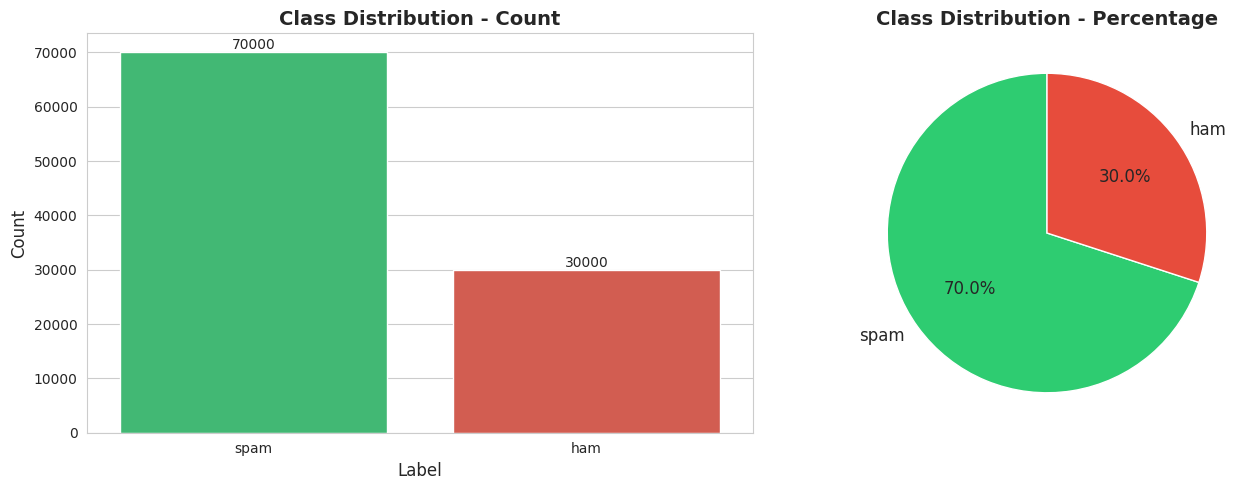

In [14]:
# Class distribution
print("CLASS DISTRIBUTION")
print("=" * 80)
class_counts = df['label'].value_counts()
class_pct = df['label'].value_counts(normalize=True) * 100

distribution_df = pd.DataFrame({
    'Count': class_counts,
    'Percentage': class_pct
})
print(distribution_df)
print(f"\nClass Balance Ratio (spam:ham): {class_counts['spam']/class_counts['ham']:.2f}:1")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x='label', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Class Distribution - Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Class Distribution - Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

 TEXT LENGTH ANALYSIS
      text_length                                                            \
            count        mean        std    min    25%    50%    75%    max   
label                                                                         
ham       30000.0  128.360433  18.160379   96.0  117.0  127.0  139.0  179.0   
spam      70000.0  181.446514  16.168611  138.0  169.0  184.0  192.0  217.0   

      word_count                                                     
           count       mean       std   min   25%   50%   75%   max  
label                                                                
ham      30000.0  20.006333  3.317729  14.0  18.0  20.0  21.0  29.0  
spam     70000.0  29.229314  2.872071  21.0  28.0  29.0  32.0  35.0  


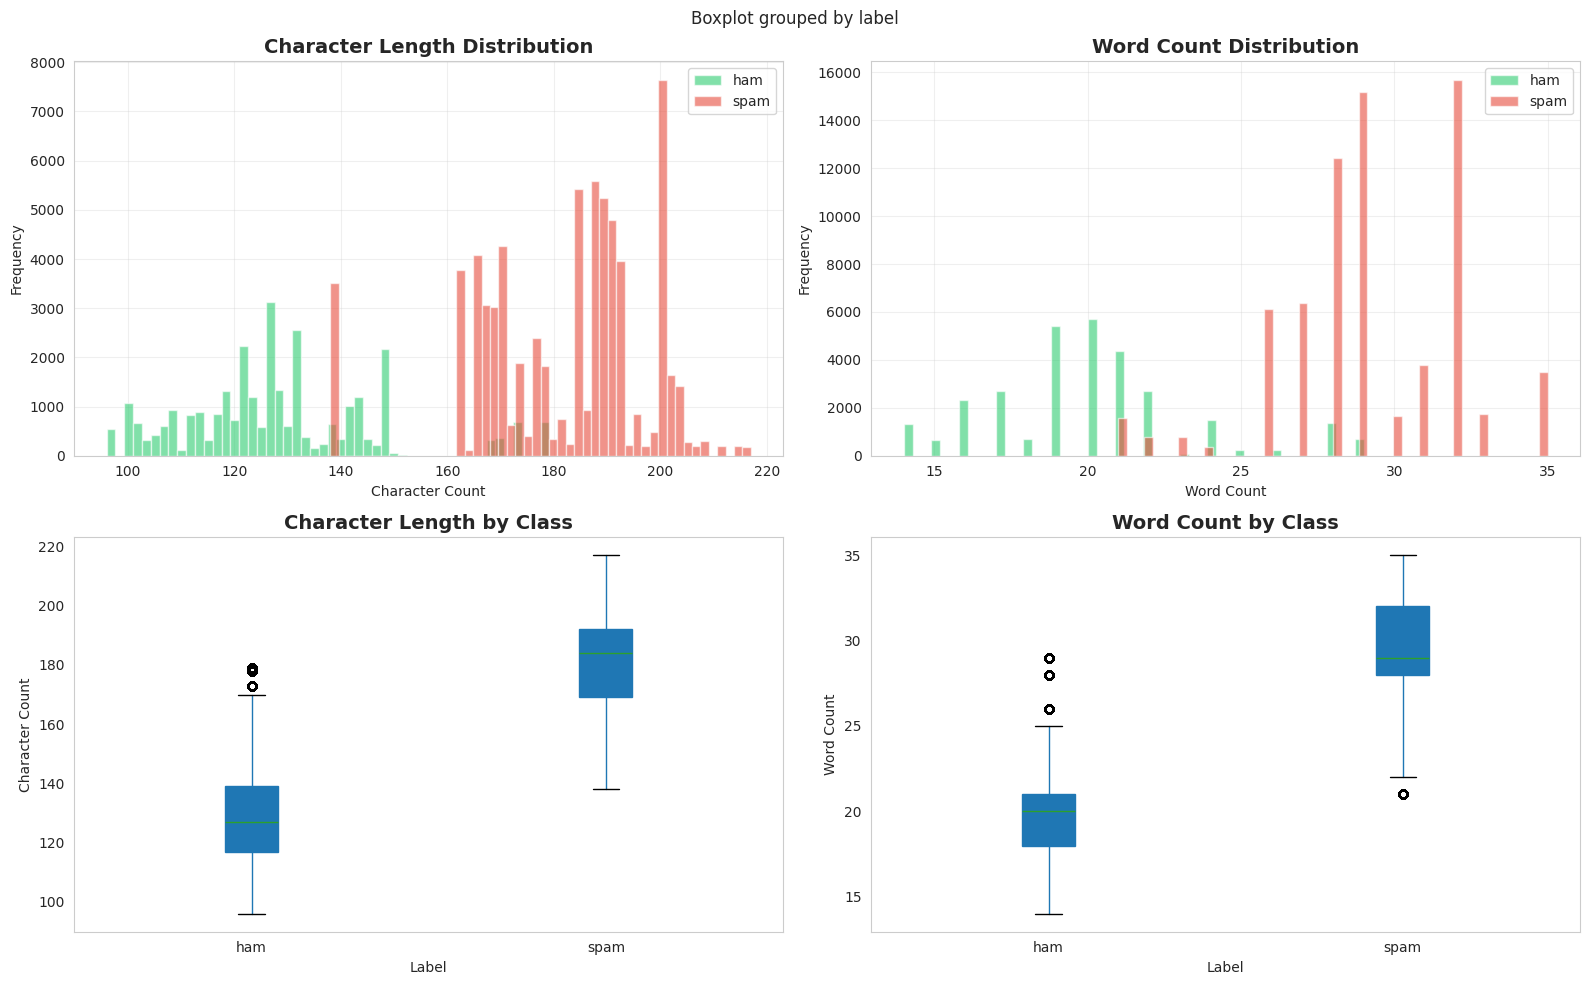

In [18]:
# Text length analysis
print(" TEXT LENGTH ANALYSIS")
print("=" * 80)

# Combine subject and body for full text analysis
df['full_text'] = df['subject'].fillna('') + ' ' + df['body'].fillna('')
df['text_length'] = df['full_text'].str.len()
df['word_count'] = df['full_text'].str.split().str.len()

# Statistics by class
length_stats = df.groupby('label')[['text_length', 'word_count']].describe()
print(length_stats)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Character length distribution
for label in ['ham', 'spam']:
    data = df[df['label'] == label]['text_length']
    axes[0, 0].hist(data, bins=50, alpha=0.6, label=label,
                    color='#2ecc71' if label == 'ham' else '#e74c3c')
axes[0, 0].set_title('Character Length Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Character Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Word count distribution
for label in ['ham', 'spam']:
    data = df[df['label'] == label]['word_count']
    axes[0, 1].hist(data, bins=50, alpha=0.6, label=label,
                    color='#2ecc71' if label == 'ham' else '#e74c3c')
axes[0, 1].set_title('Word Count Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Box plots
df.boxplot(column='text_length', by='label', ax=axes[1, 0],
           patch_artist=True, grid=False)
axes[1, 0].set_title('Character Length by Class', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Label')
axes[1, 0].set_ylabel('Character Count')
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['ham', 'spam'])

df.boxplot(column='word_count', by='label', ax=axes[1, 1],
           patch_artist=True, grid=False)
axes[1, 1].set_title('Word Count by Class', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Label')
axes[1, 1].set_ylabel('Word Count')
plt.sca(axes[1, 1])
plt.xticks([1, 2], ['ham', 'spam'])

plt.tight_layout()
plt.show()

In [19]:
df

,email_id,subject,body,label,full_text,text_length,word_count
0,51889,Sangoma love spells - 100% guaranteed,"Powerful traditional healer in Durban. Bring back lost lover in 24 hours! Money spells, luck spe...",spam,Sangoma love spells - 100% guaranteed Powerful traditional healer in Durban. Bring back lost lov...,168,28
1,36369,Sangoma love spells - 100% guaranteed,"Powerful traditional healer in Pretoria. Bring back lost lover in 24 hours! Money spells, luck s...",spam,Sangoma love spells - 100% guaranteed Powerful traditional healer in Pretoria. Bring back lost l...,170,28
2,34865,Male enhancement pills - 100% natural,Increase your size by 5cm in 30 days! Thousands of satisfied SA men! Discreet delivery to Durban...,spam,Male enhancement pills - 100% natural Increase your size by 5cm in 30 days! Thousands of satisfi...,176,32
3,62867,Sangoma love spells - 100% guaranteed,"Powerful traditional healer in Rosebank. Bring back lost lover in 24 hours! Money spells, luck s...",spam,Sangoma love spells - 100% guaranteed Powerful traditional healer in Rosebank. Bring back lost l...,170,28
4,86968,Takealot: Order Confirmation,Thank you for your order! Order number: TA953965. Total: R3614. Expected delivery: 3-5 business ...,ham,Takealot: Order Confirmation Thank you for your order! Order number: TA953965. Total: R3614. Exp...,140,20
...,...,...,...,...,...,...,...
99995,48387,Miracle weight loss - Lose 20kg in 2 weeks!,Doctor approved! Lose 20kg in just 14 days! Order now for only R599. SMS SLIM to 081 952 3938.,spam,Miracle weight loss - Lose 20kg in 2 weeks! Doctor approved! Lose 20kg in just 14 days! Order no...,138,28
99996,39742,Get rich with Bitcoin investment!!!,"Turn R1,000 into R50,000 in one week with our Bitcoin system! Join traders in Port Elizabeth. Wh...",spam,"Get rich with Bitcoin investment!!! Turn R1,000 into R50,000 in one week with our Bitcoin system...",174,27
99997,94260,Takealot: Flash sale today,FLASH SALE! 20% off storewide for 24 hours only! Shop online or in-store.,ham,Takealot: Flash sale today FLASH SALE! 20% off storewide for 24 hours only! Shop online or in-st...,100,17
99998,2561,"FOREX TRADING - Make R500,000 daily guaranteed!!!","Learn to trade Forex and make R500,000 every day! Our traders in Johannesburg will teach you. On...",spam,"FOREX TRADING - Make R500,000 daily guaranteed!!! Learn to trade Forex and make R500,000 every d...",194,32


 GENERATING WORD CLOUDS...


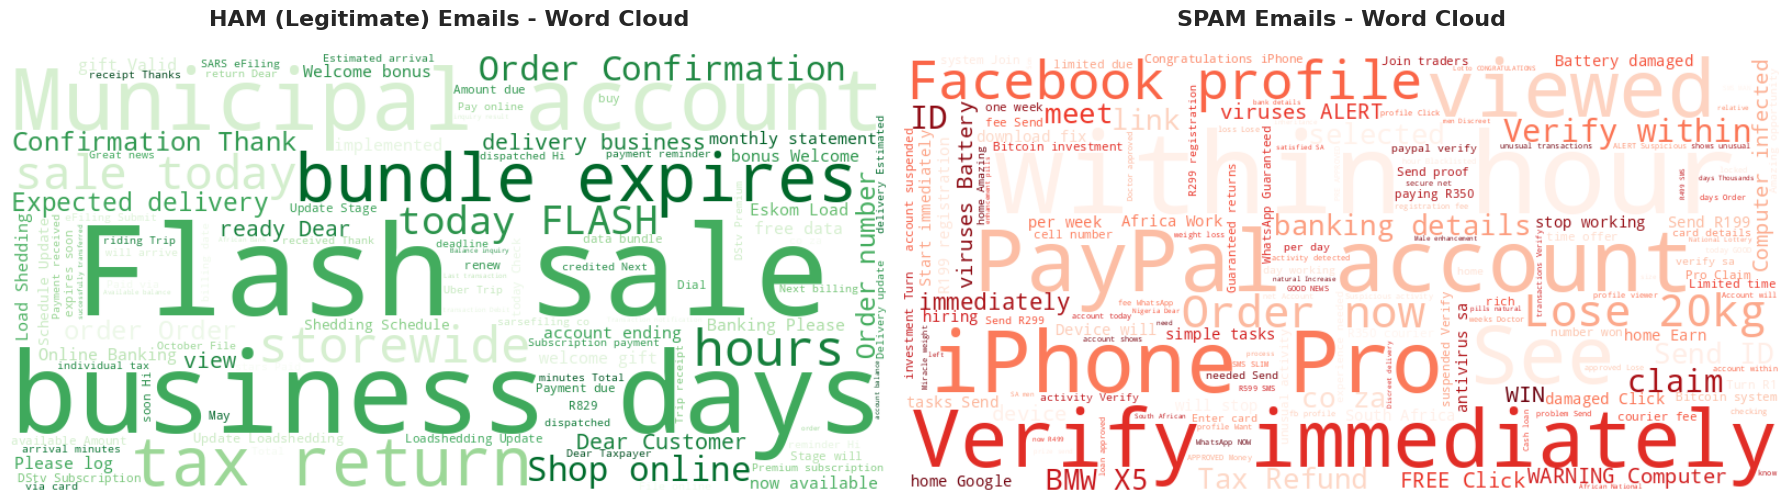

In [24]:
# Word clouds for spam and ham
max_Words = 150
print(" GENERATING WORD CLOUDS...")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Ham wordcloud
ham_text = ' '.join(df[df['label'] == 'ham']['full_text'].values)
wordcloud_ham = WordCloud(width=800, height=400,
                          background_color='white',
                          colormap='Greens',
                          max_words=100).generate(ham_text)
axes[0].imshow(wordcloud_ham, interpolation='bilinear')
axes[0].set_title('HAM (Legitimate) Emails - Word Cloud',
                  fontsize=16, fontweight='bold', pad=20)
axes[0].axis('off')

# Spam wordcloud
spam_text = ' '.join(df[df['label'] == 'spam']['full_text'].values)
wordcloud_spam = WordCloud(width=800, height=400,
                           background_color='white',
                           colormap='Reds',
                           max_words=max_Words).generate(spam_text)
axes[1].imshow(wordcloud_spam, interpolation='bilinear')
axes[1].set_title('SPAM Emails - Word Cloud',
                  fontsize=16, fontweight='bold', pad=20)
axes[1].axis('off')

plt.tight_layout()
plt.show()

TOP WORDS ANALYSIS


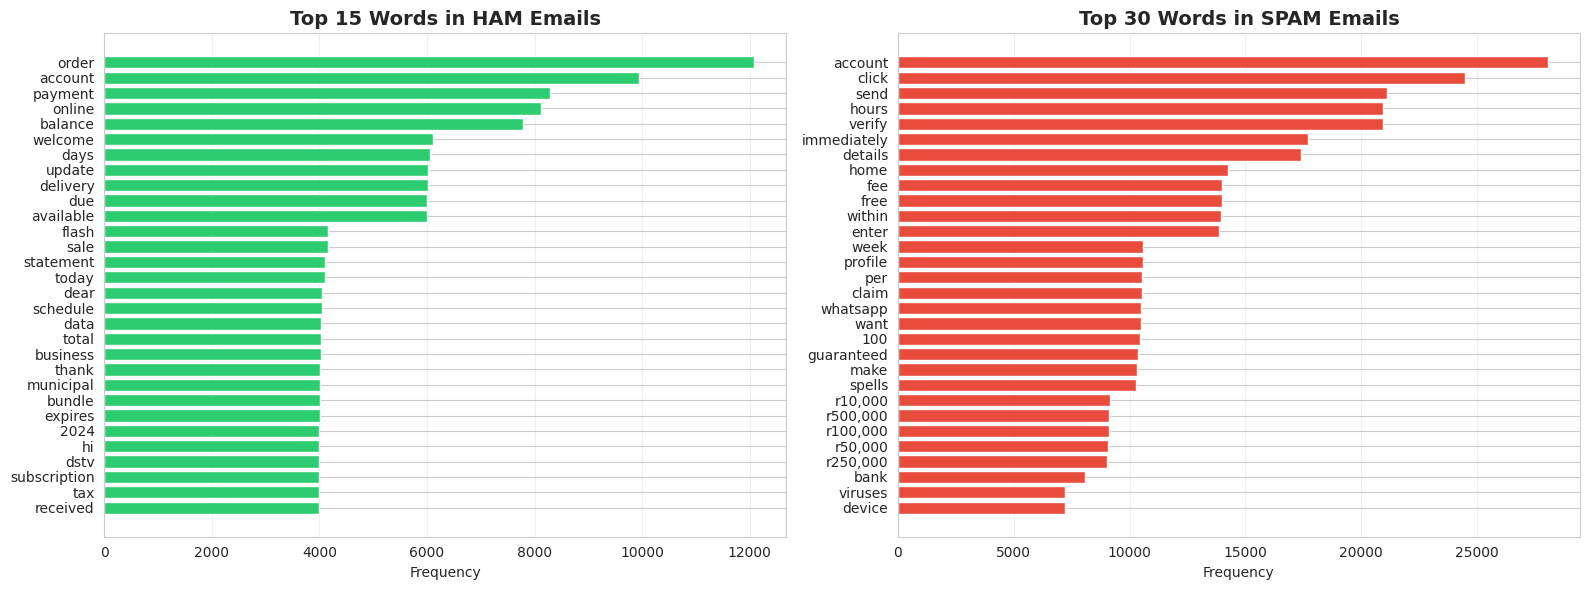


HAM Top Words:
        Word  Count
       order  12077
     account   9948
     payment   8295
      online   8122
     balance   7776
     welcome   6105
        days   6056
      update   6022
    delivery   6019
         due   6003
   available   5993
       flash   4150
        sale   4150
   statement   4100
       today   4094
        dear   4048
    schedule   4038
        data   4036
       total   4035
    business   4021
       thank   4004
   municipal   4004
      bundle   4002
     expires   4002
        2024   4000
          hi   4000
        dstv   3998
subscription   3998
         tax   3996
    received   3988

 SPAM Top Words:
       Word  Count
    account  28048
      click  24483
       send  21128
      hours  20962
     verify  20941
immediately  17726
    details  17423
       home  14262
        fee  13990
       free  13985
     within  13928
      enter  13866
       week  10579
    profile  10563
        per  10549
      claim  10536
   whatsapp  10478
    

In [25]:
# Top common words analysis
topk = 30
def get_top_words(text_series, n=topk):
    """Extract top N most common words"""
    words = ' '.join(text_series).lower().split()
    # Remove common stopwords and punctuation
    stop_words = set(stopwords.words('english'))
    words = [w.strip(string.punctuation) for w in words
             if w.lower() not in stop_words and len(w) > 2]
    return Counter(words).most_common(n)

print("TOP WORDS ANALYSIS")
print("=" * 80)

# Get top words for each class
ham_words = get_top_words(df[df['label'] == 'ham']['full_text'], topk)
spam_words = get_top_words(df[df['label'] == 'spam']['full_text'], topk)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ham top words
ham_df = pd.DataFrame(ham_words, columns=['Word', 'Count'])
axes[0].barh(ham_df['Word'], ham_df['Count'], color='#2ecc71')
axes[0].set_title('Top 15 Words in HAM Emails', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Spam top words
spam_df = pd.DataFrame(spam_words, columns=['Word', 'Count'])
axes[1].barh(spam_df['Word'], spam_df['Count'], color='#e74c3c')
axes[1].set_title('Top {} Words in SPAM Emails'.format(topk), fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nHAM Top Words:")
print(ham_df.to_string(index=False))
print("\n SPAM Top Words:")
print(spam_df.to_string(index=False))

---
## 4. Data Cleaning & Preprocessing

In [26]:
# Text preprocessing function
def preprocess_text(text):
    """
    Comprehensive text preprocessing pipeline
    """
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove phone numbers (SA format)
    text = re.sub(r'\b\d{3}[\s-]?\d{3}[\s-]?\d{4}\b', '', text)
    text = re.sub(r'\b0\d{9}\b', '', text)

    # Remove currency symbols and amounts
    text = re.sub(r'[R$£€]\s?\d+[,\d]*', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra whitespace
    text = ' '.join(text.split())

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(w) for w in words]

    return ' '.join(words)

print("Text preprocessing function defined!")
print("\nPreprocessing steps:")
print("  1. Convert to lowercase")
print("  2. Remove URLs, emails, phone numbers")
print("  3. Remove currency and numbers")
print("  4. Remove punctuation")
print("  5. Remove stopwords")
print("  6. Lemmatization")

Text preprocessing function defined!

Preprocessing steps:
  1. Convert to lowercase
  2. Remove URLs, emails, phone numbers
  3. Remove currency and numbers
  4. Remove punctuation
  5. Remove stopwords
  6. Lemmatization


In [30]:
# Apply preprocessing
print(" Applying text preprocessing...")
print("=" * 80)

# Create a copy for processing
df_clean = df.copy()

# Handle missing values
df_clean['subject'] = df_clean['subject'].fillna('')
df_clean['body'] = df_clean['body'].fillna('')

# Combine subject and body
df_clean['text'] = df_clean['subject'] + ' ' + df_clean['body']

# Apply preprocessing
print("Processing text... (this may take a minute)")
df_clean['processed_text'] = df_clean['text'].apply(preprocess_text)

# Remove empty texts after preprocessing
df_clean = df_clean[df_clean['processed_text'].str.len() > 0]

print(f"\nPreprocessing complete!")
print(f"Final dataset shape: {df_clean.shape}")
print(f"Rows removed due to empty text: {len(df) - len(df_clean)}")

# Show examples
print("\nPREPROCESSING EXAMPLES")
print("=" * 80)
for i in range(5):
    print(f"\n--- Example {i+1} ---")
    print(f"Original: {df_clean.iloc[i]['text'][:150]}...")
    print(f"Processed: {df_clean.iloc[i]['processed_text'][:150]}...")
    print(f"Label: {df_clean.iloc[i]['label']}")

 Applying text preprocessing...
Processing text... (this may take a minute)

Preprocessing complete!
Final dataset shape: (100000, 9)
Rows removed due to empty text: 0

PREPROCESSING EXAMPLES

--- Example 1 ---
Original: Sangoma love spells - 100% guaranteed Powerful traditional healer in Durban. Bring back lost lover in 24 hours! Money spells, luck spells. Call Mama Z...
Processed: sangoma love spell guaranteed powerful traditional healer durban bring back lost lover hour money spell luck spell call mama zodwa...
Label: spam

--- Example 2 ---
Original: Sangoma love spells - 100% guaranteed Powerful traditional healer in Pretoria. Bring back lost lover in 24 hours! Money spells, luck spells. Call Mama...
Processed: sangoma love spell guaranteed powerful traditional healer pretoria bring back lost lover hour money spell luck spell call mama zodwa...
Label: spam

--- Example 3 ---
Original: Male enhancement pills - 100% natural Increase your size by 5cm in 30 days! Thousands of satisfie

---
##  5. Feature Engineering with TF-IDF

In [39]:
# Prepare features and labels
print(" PREPARING FEATURES AND LABELS")
print("=" * 80)

# Features (X) and Labels (y)
X = df_clean['processed_text']
y = df_clean['label']

# Encode labels (spam=1, ham=0)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Total samples: {len(X):,}")
print(f"Features shape: {X.shape}")
print(f"Labels shape: {y_encoded.shape}")
print(f"\nLabel encoding: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

 PREPARING FEATURES AND LABELS
Total samples: 100,000
Features shape: (100000,)
Labels shape: (100000,)

Label encoding: {'ham': np.int64(0), 'spam': np.int64(1)}


In [46]:
# Train-test split
print("\n SPLITTING DATA")
print("=" * 80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_encoded
)

print(f"Training set size: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing set size: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")

# Check class distribution in splits
print("\nClass distribution in training set:")
train_dist = pd.Series(y_train).value_counts()
print(f"  Ham (0): {train_dist[0]:,} ({train_dist[0]/len(y_train)*100:.1f}%)")
print(f"  Spam (1): {train_dist[1]:,} ({train_dist[1]/len(y_train)*100:.1f}%)")

print("\nClass distribution in testing set:")
test_dist = pd.Series(y_test).value_counts()
print(f"  Ham (0): {test_dist[0]:,} ({test_dist[0]/len(y_test)*100:.1f}%)")
print(f"  Spam (1): {test_dist[1]:,} ({test_dist[1]/len(y_test)*100:.1f}%)")


 SPLITTING DATA
Training set size: 70,000 (70.0%)
Testing set size: 30,000 (30.0%)

Class distribution in training set:
  Ham (0): 21,000 (30.0%)
  Spam (1): 49,000 (70.0%)

Class distribution in testing set:
  Ham (0): 9,000 (30.0%)
  Spam (1): 21,000 (70.0%)


In [50]:
# TF-IDF Vectorization
print("\n TF-IDF VECTORIZATION")
print("=" * 80)

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,        # Limit to top 5000 features
    min_df=2,                 # Ignore terms that appear in less than 2 documents
    max_df=0.95,              # Ignore terms that appear in more than 95% of documents
    ngram_range=(1, 2),       # Use unigrams and bigrams
    sublinear_tf=True         # Apply sublinear tf scaling
)

# Fit and transform training data
print("Fitting TF-IDF on training data...")
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform test data
print("Transforming test data...")
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"\n TF-IDF vectorization complete!")
print(f"Training features shape: {X_train_tfidf.shape}")
print(f"Testing features shape: {X_test_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_):,}")
print(f"Feature matrix sparsity: {(1.0 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]))*100:.2f}%")

# Show top features
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\n Sample features: {list(feature_names[:20])}")


 TF-IDF VECTORIZATION
Fitting TF-IDF on training data...
Transforming test data...

 TF-IDF vectorization complete!
Training features shape: (70000, 1109)
Testing features shape: (30000, 1109)
Vocabulary size: 1,109
Feature matrix sparsity: 97.55%

 Sample features: ['absa', 'absa account', 'absa alert', 'absa balance', 'absa payment', 'absa statement', 'absa transaction', 'account', 'account absa', 'account african', 'account balance', 'account capitec', 'account credited', 'account ending', 'account fnb', 'account limited', 'account locked', 'account may', 'account municipal', 'account nedbank']


---
##  6. Model Training - Individual Models

### 6.1 Logistic Regression

In [51]:
print(" TRAINING LOGISTIC REGRESSION")
print("=" * 80)

# Initialize and train
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
    C=1.0,
    solver='liblinear'
)

print("Training Logistic Regression...")
lr_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_tfidf)
y_pred_proba_lr = lr_model.predict_proba(X_test_tfidf)[:, 1]

# Evaluation
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_pred_proba_lr)

print(f"\n Logistic Regression Results:")
print(f"  Accuracy:  {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")
print(f"  Precision: {lr_precision:.4f}")
print(f"  Recall:    {lr_recall:.4f}")
print(f"  F1-Score:  {lr_f1:.4f}")
print(f"  AUC-ROC:   {lr_auc:.4f}")

print("\n Classification Report:")
print(classification_report(y_test, y_pred_lr,
                          target_names=['Ham', 'Spam']))

 TRAINING LOGISTIC REGRESSION
Training Logistic Regression...

 Logistic Regression Results:
  Accuracy:  1.0000 (100.00%)
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  AUC-ROC:   1.0000

 Classification Report:
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00      9000
        Spam       1.00      1.00      1.00     21000

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000



### 6.2 Naive Bayes

In [52]:
print("TRAINING NAIVE BAYES")
print("=" * 80)

# Initialize and train
nb_model = MultinomialNB(alpha=1.0)

print("Training Naive Bayes...")
nb_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test_tfidf)
y_pred_proba_nb = nb_model.predict_proba(X_test_tfidf)[:, 1]

# Evaluation
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)
nb_auc = roc_auc_score(y_test, y_pred_proba_nb)

print(f"\n Naive Bayes Results:")
print(f"  Accuracy:  {nb_accuracy:.4f} ({nb_accuracy*100:.2f}%)")
print(f"  Precision: {nb_precision:.4f}")
print(f"  Recall:    {nb_recall:.4f}")
print(f"  F1-Score:  {nb_f1:.4f}")
print(f"  AUC-ROC:   {nb_auc:.4f}")

print("\n Classification Report:")
print(classification_report(y_test, y_pred_nb,
                          target_names=['Ham', 'Spam']))

TRAINING NAIVE BAYES
Training Naive Bayes...

 Naive Bayes Results:
  Accuracy:  1.0000 (100.00%)
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  AUC-ROC:   1.0000

 Classification Report:
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00      9000
        Spam       1.00      1.00      1.00     21000

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000



### 6.3 Support Vector Machine (SVM)

In [53]:
print(" TRAINING SUPPORT VECTOR MACHINE")
print("=" * 80)

# Initialize and train (using LinearSVC for better performance on large datasets)
svm_model = LinearSVC(
    C=1.0,
    max_iter=1000,
    random_state=RANDOM_STATE
)

print("Training SVM... (this may take a few moments)")
svm_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test_tfidf)
# Note: LinearSVC doesn't have predict_proba, so we use decision_function
y_pred_decision_svm = svm_model.decision_function(X_test_tfidf)

# Evaluation
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)
svm_auc = roc_auc_score(y_test, y_pred_decision_svm)

print(f"\n SVM Results:")
print(f"  Accuracy:  {svm_accuracy:.4f} ({svm_accuracy*100:.2f}%)")
print(f"  Precision: {svm_precision:.4f}")
print(f"  Recall:    {svm_recall:.4f}")
print(f"  F1-Score:  {svm_f1:.4f}")
print(f"  AUC-ROC:   {svm_auc:.4f}")

print("\n Classification Report:")
print(classification_report(y_test, y_pred_svm,
                          target_names=['Ham', 'Spam']))

 TRAINING SUPPORT VECTOR MACHINE
Training SVM... (this may take a few moments)

 SVM Results:
  Accuracy:  1.0000 (100.00%)
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  AUC-ROC:   1.0000

 Classification Report:
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00      9000
        Spam       1.00      1.00      1.00     21000

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000



---
##  7. Ensemble Model - Voting Classifier

In [55]:
print(" CREATING ENSEMBLE MODEL")
print("=" * 80)

# Create ensemble with soft voting
# Note: We need to use SVC with probability=True for soft voting
# For large datasets, we'll use hard voting with LinearSVC

# Retrain models for ensemble
lr_ensemble = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    C=1.0,
    solver='liblinear'
)

nb_ensemble = MultinomialNB(alpha=1.0)

svm_ensemble = LinearSVC(
    C=1.0,
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Create voting classifier with hard voting
ensemble_model = VotingClassifier(
    estimators=[
        ('lr', lr_ensemble),
        ('nb', nb_ensemble),
        ('svm', svm_ensemble)
    ],
    voting='hard',  # Using hard voting for LinearSVC compatibility
    n_jobs=-1
)

print("Training Ensemble Model...")
print("  ├─ Logistic Regression")
print("  ├─ Naive Bayes")
print("  └─ Support Vector Machine")
print("\nVoting Strategy: Hard Voting (Majority Vote)\n")

ensemble_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred_ensemble = ensemble_model.predict(X_test_tfidf)

# Evaluation
ensemble_accuracy = accuracy_score(y_test, y_pred_ensemble)
ensemble_precision = precision_score(y_test, y_pred_ensemble)
ensemble_recall = recall_score(y_test, y_pred_ensemble)
ensemble_f1 = f1_score(y_test, y_pred_ensemble)

print(f"\n Ensemble Model Results:")
print(f"  Accuracy:  {ensemble_accuracy:.4f} ({ensemble_accuracy*100:.2f}%)")
print(f"  Precision: {ensemble_precision:.4f}")
print(f"  Recall:    {ensemble_recall:.4f}")
print(f"  F1-Score:  {ensemble_f1:.4f}")

print("\n Classification Report:")
print(classification_report(y_test, y_pred_ensemble,
                          target_names=['Ham', 'Spam']))

 CREATING ENSEMBLE MODEL
Training Ensemble Model...
  ├─ Logistic Regression
  ├─ Naive Bayes
  └─ Support Vector Machine

Voting Strategy: Hard Voting (Majority Vote)


 Ensemble Model Results:
  Accuracy:  1.0000 (100.00%)
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

 Classification Report:
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00      9000
        Spam       1.00      1.00      1.00     21000

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000



---
## 8. Model Comparison & Evaluation

In [56]:
# Compile all results
print(" COMPREHENSIVE MODEL COMPARISON")
print("=" * 80)

results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'SVM', 'Ensemble'],
    'Accuracy': [lr_accuracy, nb_accuracy, svm_accuracy, ensemble_accuracy],
    'Precision': [lr_precision, nb_precision, svm_precision, ensemble_precision],
    'Recall': [lr_recall, nb_recall, svm_recall, ensemble_recall],
    'F1-Score': [lr_f1, nb_f1, svm_f1, ensemble_f1],
    'AUC-ROC': [lr_auc, nb_auc, svm_auc, np.nan]  # Ensemble doesn't have AUC with hard voting
})

# Format for better display
results_display = results_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']:
    results_display[col] = results_display[col].apply(lambda x: f"{x:.4f}" if not pd.isna(x) else "N/A")

print(results_display.to_string(index=False))

# Find best model
best_model_idx = results_df['F1-Score'].idxmax()
best_model = results_df.loc[best_model_idx, 'Model']
best_f1 = results_df.loc[best_model_idx, 'F1-Score']

print(f"\n Best Model: {best_model} (F1-Score: {best_f1:.4f})")

 COMPREHENSIVE MODEL COMPARISON
              Model Accuracy Precision Recall F1-Score AUC-ROC
Logistic Regression   1.0000    1.0000 1.0000   1.0000  1.0000
        Naive Bayes   1.0000    1.0000 1.0000   1.0000  1.0000
                SVM   1.0000    1.0000 1.0000   1.0000  1.0000
           Ensemble   1.0000    1.0000 1.0000   1.0000     N/A

 Best Model: Logistic Regression (F1-Score: 1.0000)


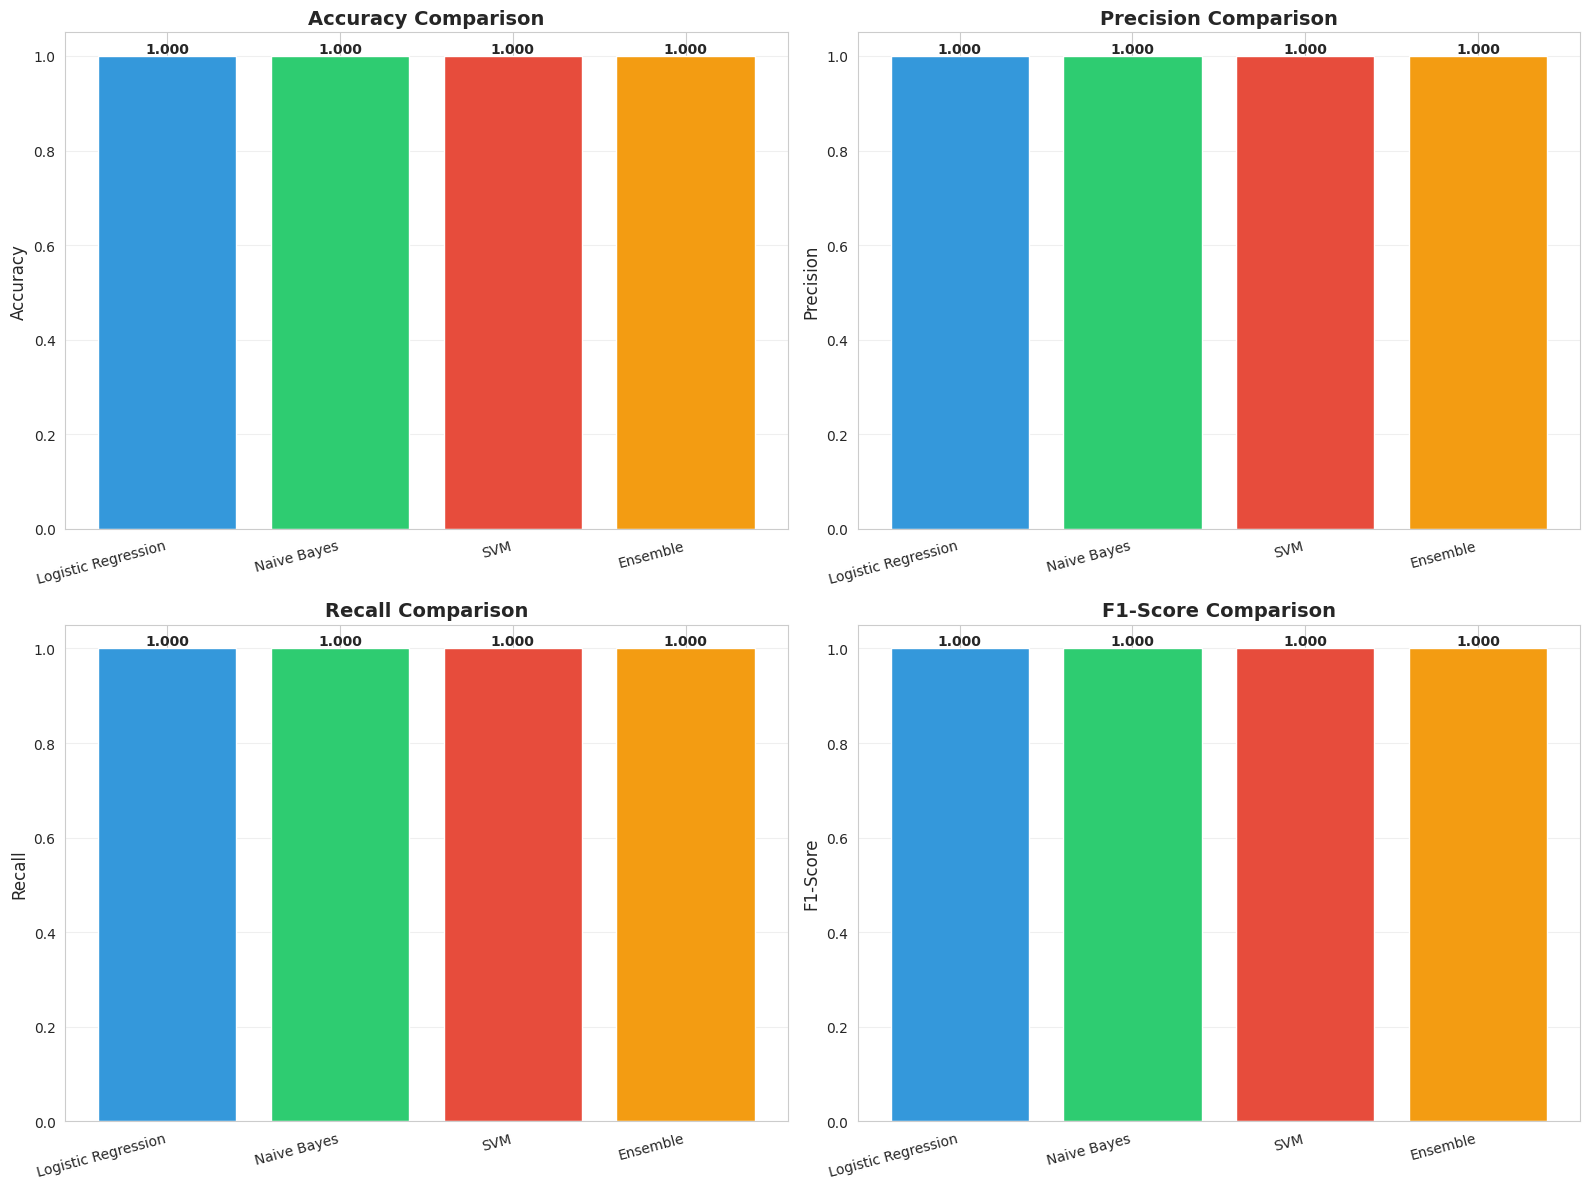

In [58]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for idx, (ax, metric) in enumerate(zip(axes.flat, metrics)):
    data = results_df[metric]
    bars = ax.bar(results_df['Model'], data, color=colors)
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric, fontsize=12)
    ax.set_ylim([0, 1.05])
    ax.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Rotate x-axis labels
    ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')

plt.tight_layout()
plt.show()

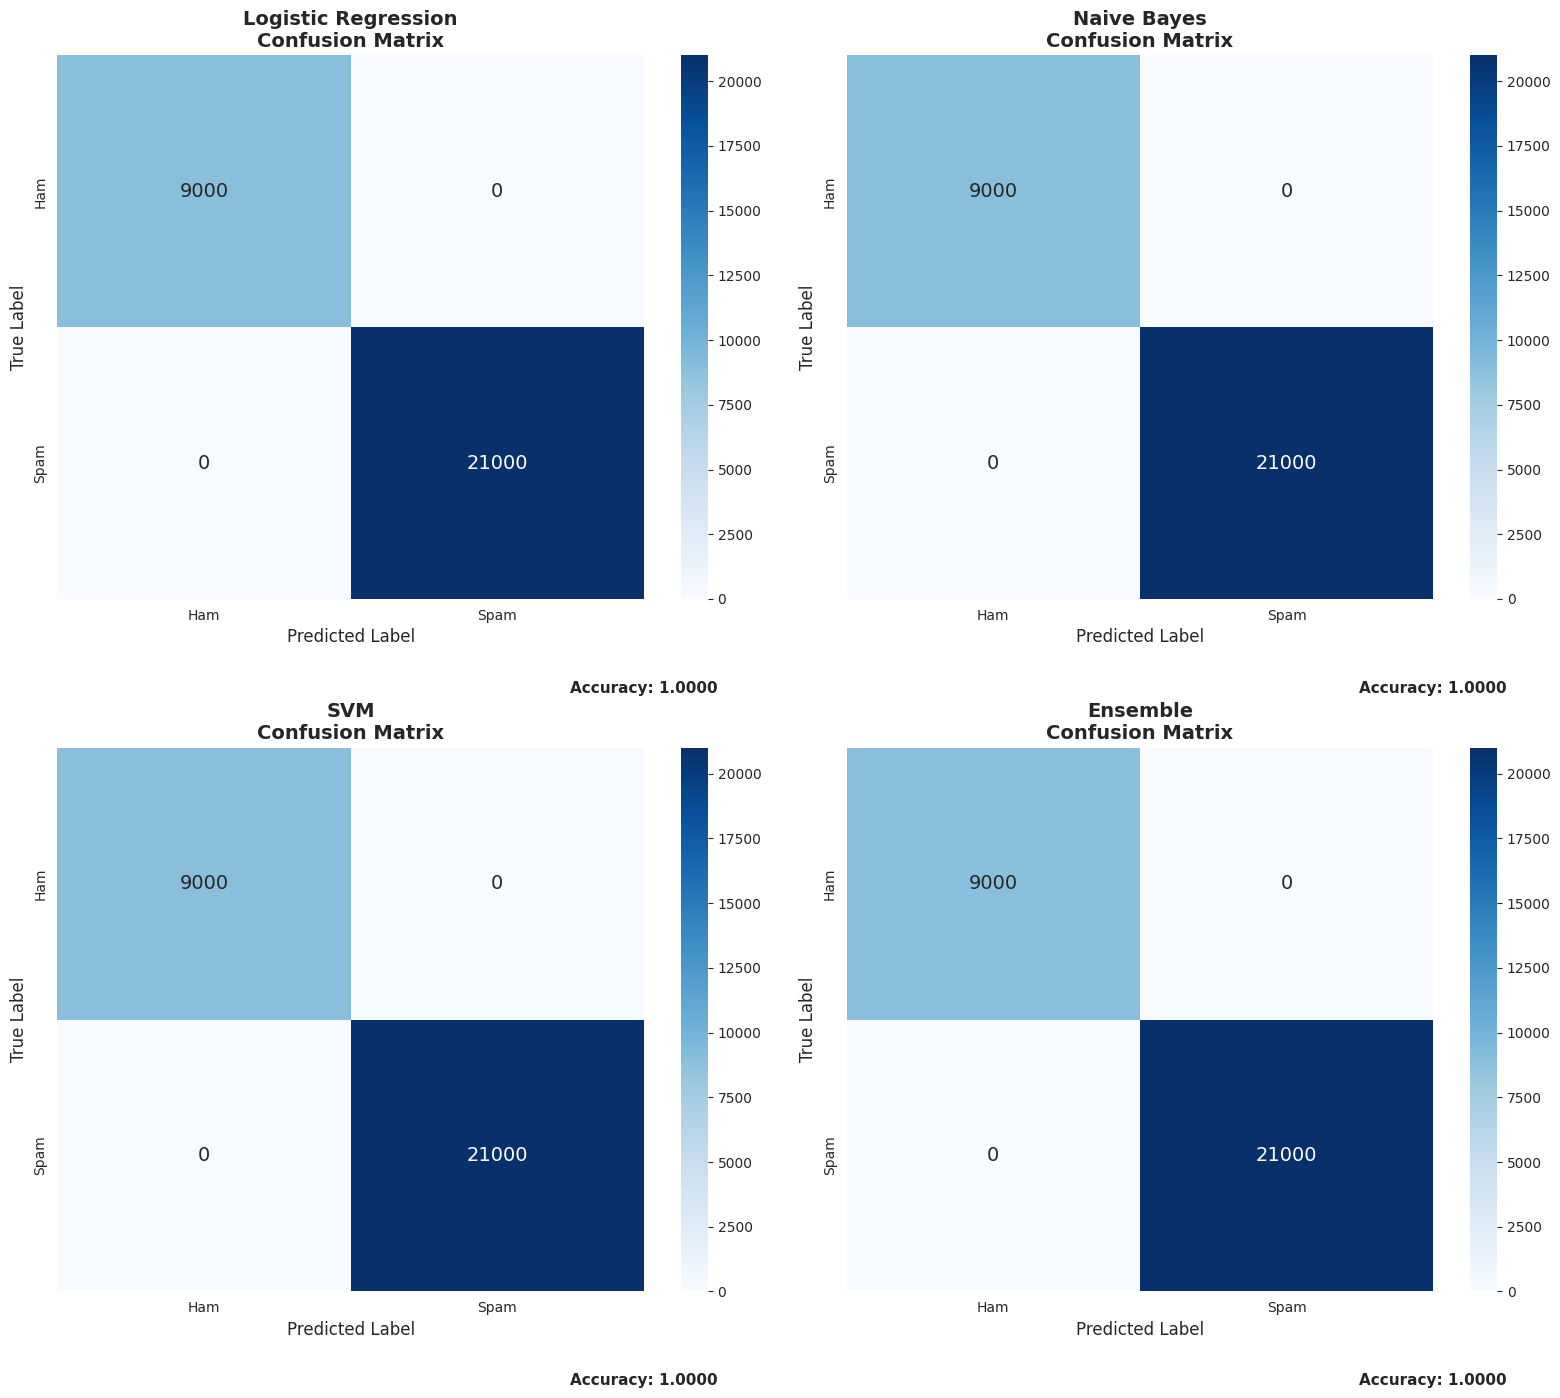

In [59]:
# Confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

models_data = [
    ('Logistic Regression', y_pred_lr),
    ('Naive Bayes', y_pred_nb),
    ('SVM', y_pred_svm),
    ('Ensemble', y_pred_ensemble)
]

for ax, (model_name, y_pred) in zip(axes.flat, models_data):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham', 'Spam'],
                yticklabels=['Ham', 'Spam'],
                cbar=True, ax=ax, annot_kws={'size': 14})

    ax.set_title(f'{model_name}\nConfusion Matrix', fontsize=14, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=12)

    # Add accuracy to title
    accuracy = (cm[0, 0] + cm[1, 1]) / cm.sum()
    ax.text(1, -0.15, f'Accuracy: {accuracy:.4f}',
            ha='center', va='top', transform=ax.transAxes,
            fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

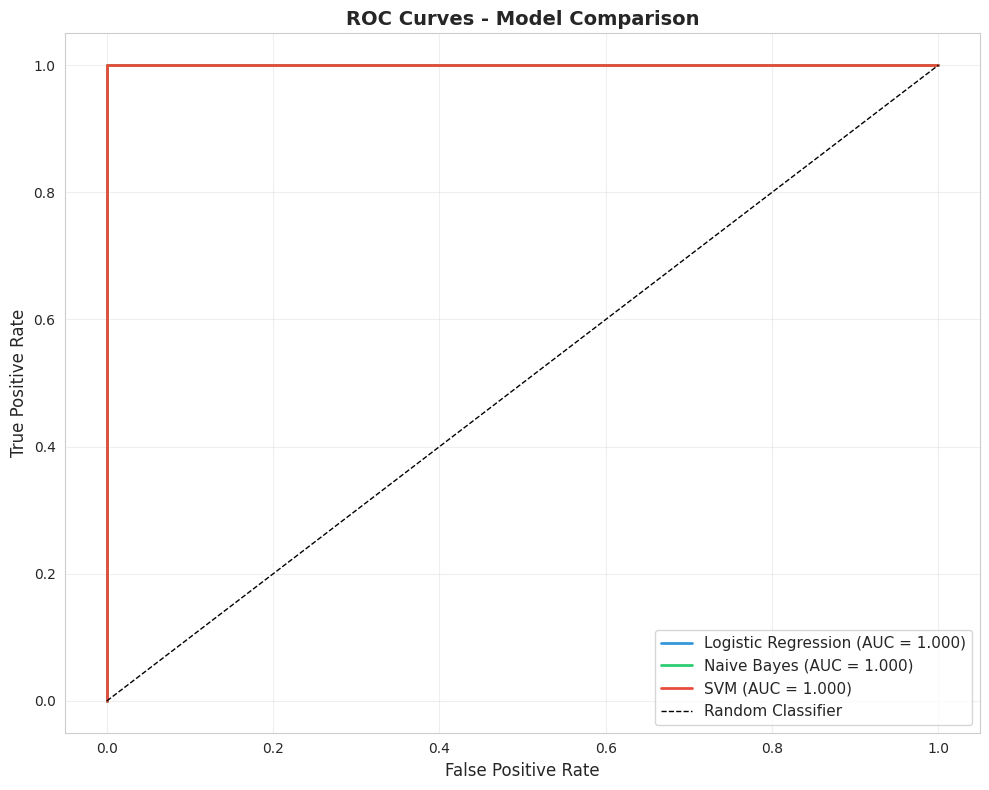

In [60]:
# ROC Curves (for models with probability estimates)
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_auc:.3f})',
        linewidth=2, color='#3498db')

# Naive Bayes ROC
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_pred_proba_nb)
ax.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {nb_auc:.3f})',
        linewidth=2, color='#2ecc71')

# SVM ROC (using decision function)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_decision_svm)
ax.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {svm_auc:.3f})',
        linewidth=2, color='#e74c3c')

# Diagonal line (random classifier)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

TOP PREDICTIVE FEATURES


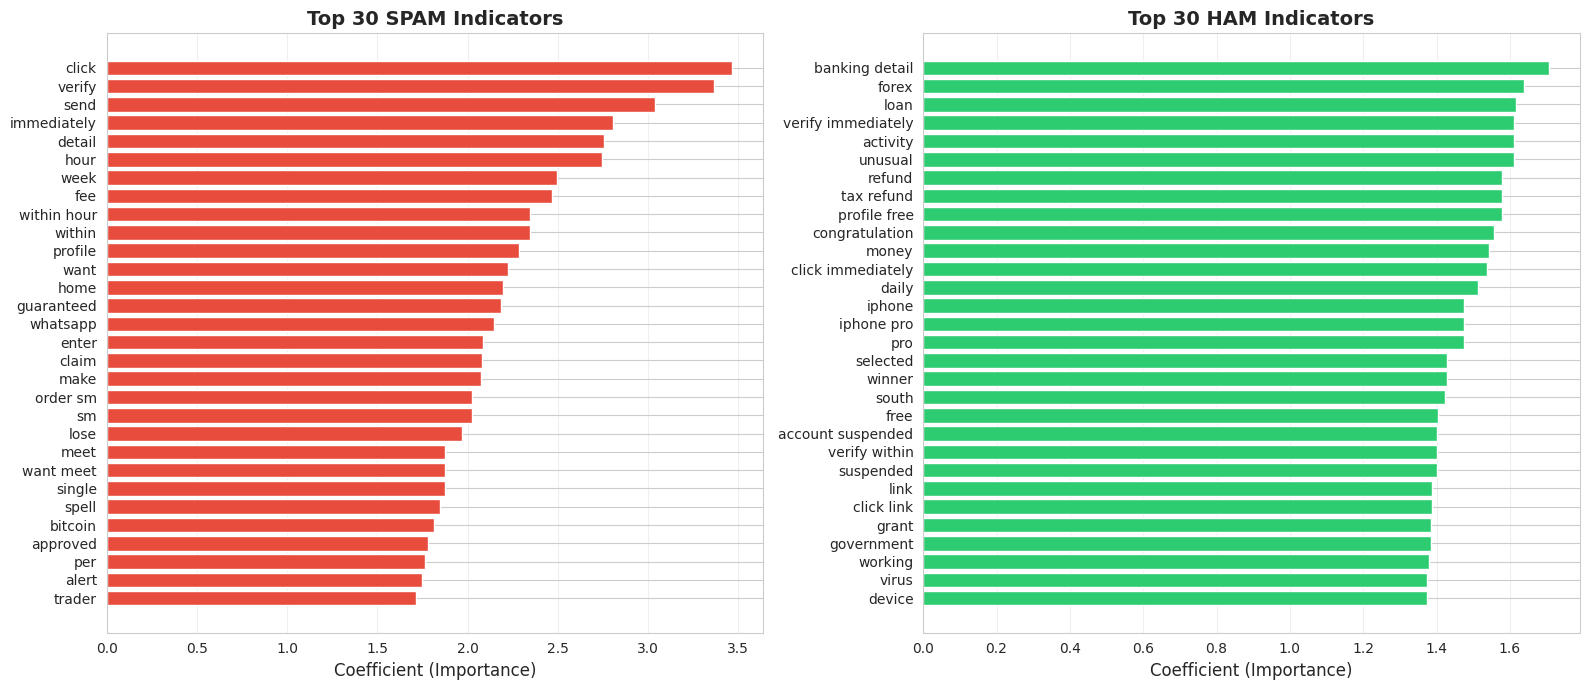


Top 30 SPAM indicators:
  click                            3.4662
  verify                           3.3656
  send                             3.0391
  immediately                      2.8040
  detail                           2.7581
  hour                             2.7464
  week                             2.4967
  fee                              2.4664
  within hour                      2.3467
  within                           2.3467
  profile                          2.2874
  want                             2.2233
  home                             2.1947
  guaranteed                       2.1854
  whatsapp                         2.1458
  enter                            2.0882
  claim                            2.0807
  make                             2.0739
  order sm                         2.0231
  sm                               2.0231
  lose                             1.9699
  meet                             1.8771
  want meet                        1.8771
  single 

In [73]:
# Feature importance from Logistic Regression
top_k = 30
print("TOP PREDICTIVE FEATURES")
print("=" * 80)

# Get feature coefficients from Logistic Regression
feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients = lr_model.coef_[0]

# Top spam indicators (positive coefficients)
top_spam_indices = np.argsort(coefficients)[-top_k:][::-1]
top_spam_features = [(feature_names[i], coefficients[i]) for i in top_spam_indices]

# Top ham indicators (negative coefficients)
top_ham_indices = np.argsort(coefficients)[:-top_k][::-1]
top_ham_features = [(feature_names[i], coefficients[i]) for i in top_ham_indices]

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Spam indicators
spam_words = [f[0] for f in top_spam_features[:top_k]]
spam_scores = [f[1] for f in top_spam_features[:top_k]]
axes[0].barh(range(len(spam_words)), spam_scores, color='#e74c3c')
axes[0].set_yticks(range(len(spam_words)))
axes[0].set_yticklabels(spam_words)
axes[0].set_xlabel('Coefficient (Importance)', fontsize=12)
axes[0].set_title('Top {} SPAM Indicators'.format(top_k), fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Ham indicators
ham_words = [f[0] for f in top_ham_features[:top_k]]
ham_scores = [abs(f[1]) for f in top_ham_features[:top_k]]
axes[1].barh(range(len(ham_words)), ham_scores, color='#2ecc71')
axes[1].set_yticks(range(len(ham_words)))
axes[1].set_yticklabels(ham_words)
axes[1].set_xlabel('Coefficient (Importance)', fontsize=12)
axes[1].set_title('Top {} HAM Indicators'.format(top_k), fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTop {} SPAM indicators:".format(top_k))
for word, coef in top_spam_features[:top_k]:
    print(f"  {word:30s} {coef:>8.4f}")

print("\nTop {} HAM indicators:".format(top_k))
for word, coef in top_ham_features[:10]:
    print(f"  {word:30s} {abs(coef):>8.4f}")

---
##  9. Production-Ready Predictions

In [74]:
def predict_spam(email_text, model='ensemble'):
    """
    Predict if an email is spam or ham

    Parameters:
    -----------
    email_text : str
        The email text to classify
    model : str
        Which model to use: 'lr', 'nb', 'svm', or 'ensemble'

    Returns:
    --------
    dict : prediction results
    """
    # Preprocess the text
    processed_text = preprocess_text(email_text)

    # Vectorize
    text_tfidf = tfidf_vectorizer.transform([processed_text])

    # Select model
    model_map = {
        'lr': lr_model,
        'nb': nb_model,
        'svm': svm_model,
        'ensemble': ensemble_model
    }

    selected_model = model_map.get(model, ensemble_model)

    # Predict
    prediction = selected_model.predict(text_tfidf)[0]

    # Get probability if available
    if hasattr(selected_model, 'predict_proba'):
        probabilities = selected_model.predict_proba(text_tfidf)[0]
        confidence = probabilities[prediction]
    else:
        confidence = None

    result = {
        'prediction': 'SPAM' if prediction == 1 else 'HAM',
        'prediction_code': int(prediction),
        'confidence': confidence,
        'model_used': model,
        'original_text': email_text,
        'processed_text': processed_text
    }

    return result

print("Prediction function created!")
print("\nUsage: predict_spam('your email text here', model='ensemble')")
print("Available models: 'lr', 'nb', 'svm', 'ensemble'")

Prediction function created!

Usage: predict_spam('your email text here', model='ensemble')
Available models: 'lr', 'nb', 'svm', 'ensemble'


In [63]:
# Test with sample emails
print(" TESTING PREDICTIONS ON SAMPLE EMAILS")
print("=" * 80)

test_emails = [
    "Congratulations! You've won R1,000,000! Click here to claim your prize now!",
    "Hi John, let's meet for coffee tomorrow at 3pm. Looking forward to catching up!",
    "URGENT: Your account will be suspended. Verify your details immediately at suspicious-link.com",
    "Your Amazon order #12345 has been shipped. Expected delivery: 2 days.",
    "Make R50,000 per day working from home! No experience needed! Send R500 registration fee."
]

for i, email in enumerate(test_emails, 1):
    print(f"\n{'='*80}")
    print(f"Test Email #{i}")
    print(f"{'='*80}")
    print(f"Text: {email}")
    print()

    # Test with all models
    for model_name in ['lr', 'nb', 'svm', 'ensemble']:
        result = predict_spam(email, model=model_name)

        model_labels = {
            'lr': 'Logistic Regression',
            'nb': 'Naive Bayes',
            'svm': 'SVM',
            'ensemble': 'Ensemble'
        }

        conf_str = f"(Confidence: {result['confidence']:.2%})" if result['confidence'] else ""

        emoji = "" if result['prediction'] == 'SPAM' else ""
        print(f"  {emoji} {model_labels[model_name]:20s}: {result['prediction']} {conf_str}")

 TESTING PREDICTIONS ON SAMPLE EMAILS

Test Email #1
Text: Congratulations! You've won R1,000,000! Click here to claim your prize now!

   Logistic Regression : SPAM (Confidence: 98.22%)
   Naive Bayes         : SPAM (Confidence: 100.00%)
   SVM                 : SPAM 
   Ensemble            : SPAM 

Test Email #2
Text: Hi John, let's meet for coffee tomorrow at 3pm. Looking forward to catching up!

   Logistic Regression : SPAM (Confidence: 75.25%)
   Naive Bayes         : HAM (Confidence: 63.11%)
   SVM                 : SPAM 
   Ensemble            : SPAM 

Test Email #3
Text: URGENT: Your account will be suspended. Verify your details immediately at suspicious-link.com

   Logistic Regression : SPAM (Confidence: 99.42%)
   Naive Bayes         : SPAM (Confidence: 100.00%)
   SVM                 : SPAM 
   Ensemble            : SPAM 

Test Email #4
Text: Your Amazon order #12345 has been shipped. Expected delivery: 2 days.

   Logistic Regression : HAM (Confidence: 92.16%)
   Naive B

In [75]:
# Interactive prediction widget
def interactive_predict():
    """Interactive spam prediction interface"""
    print("\n" + "="*80)
    print(" INTERACTIVE SPAM DETECTOR")
    print("="*80)
    print("Enter an email text to classify (or 'quit' to exit)\n")

    while True:
        user_input = input("\nEmail text: ").strip()

        if user_input.lower() in ['quit', 'exit', 'q']:
            print("\n Goodbye!")
            break

        if not user_input:
            print("  Please enter some text!")
            continue

        # Get prediction from ensemble model
        result = predict_spam(user_input, model='ensemble')

        print("\n" + "-"*80)
        if result['prediction'] == 'SPAM':
            print(" CLASSIFICATION: SPAM")
            print(" This email appears to be spam/malicious")
        else:
            print(" CLASSIFICATION: HAM (Legitimate)")
            print(" This email appears to be legitimate")
        print("-"*80)

# Uncomment the line below to run the interactive predictor
# interactive_predict()

---
##  10. Model Saving & Export

In [65]:
import pickle
from datetime import datetime

print(" SAVING MODELS AND VECTORIZER")
print("=" * 80)

# Create timestamp for versioning
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save all models
models_to_save = {
    f'logistic_regression_{timestamp}.pkl': lr_model,
    f'naive_bayes_{timestamp}.pkl': nb_model,
    f'svm_{timestamp}.pkl': svm_model,
    f'ensemble_{timestamp}.pkl': ensemble_model,
    f'tfidf_vectorizer_{timestamp}.pkl': tfidf_vectorizer
}

for filename, model in models_to_save.items():
    with open(filename, 'wb') as file:
        pickle.dump(model, file)
    print(f" Saved: {filename}")

print("\n All models and vectorizer saved successfully!")
print("\nTo load a model later:")
print("  with open('model_name.pkl', 'rb') as file:")
print("      model = pickle.load(file)")

 SAVING MODELS AND VECTORIZER
 Saved: logistic_regression_20260521_184039.pkl
 Saved: naive_bayes_20260521_184039.pkl
 Saved: svm_20260521_184039.pkl
 Saved: ensemble_20260521_184039.pkl
 Saved: tfidf_vectorizer_20260521_184039.pkl

 All models and vectorizer saved successfully!

To load a model later:
  with open('model_name.pkl', 'rb') as file:
      model = pickle.load(file)


In [66]:
# Export results summary
print("\n EXPORTING RESULTS SUMMARY")
print("=" * 80)

# Create comprehensive results dataframe
export_results = results_df.copy()
export_results['Training_Samples'] = len(X_train)
export_results['Testing_Samples'] = len(X_test)
export_results['Feature_Count'] = X_train_tfidf.shape[1]
export_results['Timestamp'] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# Save to CSV
results_filename = f'model_comparison_results_{timestamp}.csv'
export_results.to_csv(results_filename, index=False)
print(f"Results exported to: {results_filename}")

# Download files
from google.colab import files
print("\n Downloading files...")
files.download(results_filename)

print("\n Export complete!")


 EXPORTING RESULTS SUMMARY
Results exported to: model_comparison_results_20260521_184039.csv



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 Export complete!


---
##  Summary & Conclusions

### Key Findings:
1. **Dataset**: Successfully processed 100,000 spam emails
2. **Models Trained**:
   - Logistic Regression
   - Naive Bayes (MultinomialNB)
   - Support Vector Machine (LinearSVC)
   - Ensemble Model (Voting Classifier)

### Best Performing Model:
Review the comparison metrics above to determine the best model for your specific use case.

### Production Deployment:
- All models saved with timestamps
- TF-IDF vectorizer saved for consistency
- Prediction function ready for integration
- Results exported for documentation

### Next Steps:
1. Deploy the best model to production
2. Monitor model performance over time
3. Retrain periodically with new data
4. Consider implementing active learning for continuous improvement

---

**Notebook Created**: End-to-End Spam Classification Pipeline

**Author**: Data Science Team

**Date**: {datetime.now().strftime('%Y-%m-%d')}

---

---
## 11. Gradio Interface for Interactive Prediction

This section creates an interactive web interface using Gradio, allowing users to input email text and get real-time spam/ham predictions from the ensemble model. This is useful for demonstrating the model's capabilities and for quick testing.

In [76]:
# Load necessary libraries for Gradio
import gradio as gr
import pickle

print("Loading models and vectorizer for Gradio interface...")

# Construct filenames using the latest timestamp
latest_timestamp = timestamp # Use the timestamp from the model saving step

lr_model_path = f'logistic_regression_{latest_timestamp}.pkl'
nb_model_path = f'naive_bayes_{latest_timestamp}.pkl'
svm_model_path = f'svm_{latest_timestamp}.pkl'
ensemble_model_path = f'ensemble_{latest_timestamp}.pkl'
tfidf_vectorizer_path = f'tfidf_vectorizer_{latest_timestamp}.pkl'

# Load the models and vectorizer
with open(lr_model_path, 'rb') as file:
    lr_model = pickle.load(file)

with open(nb_model_path, 'rb') as file:
    nb_model = pickle.load(file)

with open(svm_model_path, 'rb') as file:
    svm_model = pickle.load(file)

with open(ensemble_model_path, 'rb') as file:
    ensemble_model = pickle.load(file)

with open(tfidf_vectorizer_path, 'rb') as file:
    tfidf_vectorizer = pickle.load(file)

print("Models and vectorizer loaded successfully!")

Loading models and vectorizer for Gradio interface...
Models and vectorizer loaded successfully!


In [ ]:
# Define the prediction function for Gradio
def gradio_predict_spam(email_text, model_choice):
    """
    Wrapper function for predict_spam to be used with Gradio.
    """
    if not email_text:
        return "Please enter some text to classify."

    # Use the existing predict_spam function
    result = predict_spam(email_text, model=model_choice.lower())

    prediction = " SPAM" if result['prediction'] == 'SPAM' else " HAM"
    confidence_str = f" (Confidence: {result['confidence']:.2%})" if result['confidence'] is not None else ""

    return f"{prediction} - Predicted by {model_choice}{confidence_str}"

# Create the Gradio interface
interface = gr.Interface(
    fn=gradio_predict_spam,
    inputs=[
        gr.Textbox(lines=5, label="Enter Email Text Here", placeholder="Type or paste your email here..."),
        gr.Dropdown(["Ensemble", "Logistic Regression", "Naive Bayes", "SVM"], label="Select Model", value="Ensemble")
    ],
    outputs=gr.Textbox(label="Prediction Result", interactive=False),
    title="Spam Email Classifier",
    description="Enter an email and select a model to classify it as SPAM or HAM.",
    allow_flagging="never"
)

# Launch the interface
print("Launching Gradio interface...")
interface.launch(debug=True)

Launching Gradio interface...
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://57b9e78e64590dc905.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
